In [184]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, List, Optional, Literal
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage
from pydantic import BaseModel, Field
from langchain_core.tools import tool
from bson import ObjectId
import json
from datetime import datetime, timedelta
import pytz
from tavily import TavilyClient
from langchain_core.messages import ToolMessage
import json


In [185]:
load_dotenv()

True

In [186]:

client = MongoClient(os.getenv("MONGODB_URL"))
db = client["MindMirror"]

In [187]:
db

Database(MongoClient(host=['ac-j6damt0-shard-00-00.ggqivfe.mongodb.net:27017', 'ac-j6damt0-shard-00-01.ggqivfe.mongodb.net:27017', 'ac-j6damt0-shard-00-02.ggqivfe.mongodb.net:27017'], document_class=dict, tz_aware=False, connect=True, appname='Cluster0', authsource='admin', replicaset='atlas-y4od37-shard-0', tls=True), 'MindMirror')

In [188]:
session = db.sessions.find_one()

In [189]:
session

{'_id': ObjectId('69f4efcbde6af0a1cc5c0c0e'),
 'user': ObjectId('69f47cd803f7c50ab862235b'),
 'url': 'https://www.flipkart.com/',
 'title': 'Online Shopping Site for Mobiles, Electronics, Furniture, Grocery, Lifestyle, Books & More. Best Offers!',
 'domain': 'www.flipkart.com',
 'timeSpent': 37898,
 'openedAt': '1/5/2026, 11:48:36 pm',
 'closedAt': '1/5/2026, 11:49:14 pm',
 'timeZone': 'Asia/Calcutta',
 'extractedText': '{"headings":["Flipkart: India\'s Ultimate One-Stop Online Shopping Destination","What Can You Buy from Flipkart?","Flipkart Loyalty and Rewards Program","Payment and Affordability: Shop Smart, Pay Smarter","Flipkart Flights: Book Your Next Getaway Effortlessly","Flipkart Minutes: Groceries and Gadgets in a Flash","Flipkart Reset and Exchange Program: Trade-in Your Old Device","Flipkart Kilos: Your Online Grocery Supermarket","Why Choose Flipkart? The Unbeatable Advantages","Get Exclusive Offers and Deals in Popular Sale Events"],"body":""}',
 '__v': 0,
 'createdAt': da

In [190]:
model=ChatOpenAI(model="gpt-4o-mini")

In [191]:
class ChatState(TypedDict):
    user_id: str
    user_name: str
    timezone:  str 
    query: str
    prompt: str
    messages: Annotated[List[BaseMessage], add_messages]

In [192]:
class Source(BaseModel):
    url: Annotated[str, Field(description="Full URL of the visited webpage")]
    title: Annotated[str, Field(description="Page title captured from the browser tab")]
    domain: Annotated[str, Field(description="Domain name e.g. www.flipkart.com")]
    openedAt: Annotated[str, Field(description="Timestamp when user opened this page in D/M/YYYY format")]
    timeSpent: Annotated[int, Field(description="Time spent on page in milliseconds")]

In [193]:
class MindMirrorResponse(BaseModel):
    answer: Annotated[str, Field(description="Conversational response addressing the user directly based on their browsing history")]
    sources: Annotated[list[Source], Field(description="List of browsing sessions used to generate this answer, only from actual tool results")]
    suggestions: Annotated[Optional[list[str]], Field(default=None, description="Optional list of related URLs or topics worth revisiting based on browsing patterns")]
    follow_up_questions: Annotated[Optional[list[str]], Field(default=None, description="Optional list of 2-3 natural follow up questions the user might want to ask next")]

In [194]:
@tool
def search_browsing_history(
    user_id: str,
    query: str = None,
    domain: str = None,
    date: str = None,
    limit: int = 10
) -> str:
    """
    Search user's browsing history from MongoDB.
    Use this tool when user asks about their browsing activity.
    
    Args:
        user_id: The user's MongoDB ObjectId string (required)
        query:   keyword to search in title and extractedText (optional)
        domain:  specific domain to filter e.g. 'youtube.com' (optional)
        date:    date string to filter by e.g. '1/5/2026' (optional)
        limit:   max number of sessions to return (default 10)
    
    Returns:
        JSON string of matching sessions
    """
    try:
        
        filter = { "user": ObjectId(user_id) }

        # domain filter
        if domain:
            filter["domain"] = { "$regex": domain, "$options": "i" }

        # date filter on openedAt
        if date:
            filter["openedAt"] = { "$regex": date, "$options": "i" }

        # text search on title and extractedText
        if query:
            filter["$or"] = [
                { "title":         { "$regex": query, "$options": "i" } },
                { "extractedText": { "$regex": query, "$options": "i" } }
            ]

        sessions = list(
            db.sessions
            .find(filter)
            .sort("openedAt", -1)
            .limit(limit)
        )

        if not sessions:
            return json.dumps({ "message": "No sessions found matching your query" })

        # clean up ObjectId fields for JSON serialization
        results = []
        for session in sessions:
            results.append({
                "url": session.get("url", ""),
                "title": session.get("title", ""),
                "domain": session.get("domain", ""),
                "openedAt": session.get("openedAt", ""),
                "closedAt": session.get("closedAt", ""),
                "timeSpent": session.get("timeSpent", 0),
                "timezone": session.get("timeZone", ""),
                "extractedText": session.get("extractedText", "")
            })

        return json.dumps(results, ensure_ascii=False)

    except Exception as e:
        return json.dumps({ "error": str(e) })

In [195]:
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [196]:
@tool
def tavily_search(query: str) -> str:
    """
    Search the web or fetch content from a specific URL for deeper context.
    Use this ONLY after search_browsing_history has already been called.
    Use when extractedText from browsing history is insufficient.
    
    Args:
        query: topic or page title to search for additional context
    
    Returns:
        JSON string with search results and content
    """
    try:
        result = tavily_client.search(
            query=query,
            max_results=3,
            include_raw_content=True
        )
        return json.dumps(result, ensure_ascii=False)
    except Exception as e:
        return json.dumps({ "error": str(e) })

In [197]:
tools=[search_browsing_history, tavily_search]

In [198]:
model_with_tools=model.bind_tools(tools)
model_structured = model.with_structured_output(MindMirrorResponse)

In [199]:
def get_date_context(timezone: str) -> dict:
    tz = pytz.timezone(timezone)
    now = datetime.now(tz)
    yesterday = now - timedelta(days=1)
    
    # Windows compatible - removes leading zeros manually
    today_storage = f"{now.day}/{now.month}/{now.year}"
    yesterday_storage = f"{yesterday.day}/{yesterday.month}/{yesterday.year}"
    
    return {
        "current_time": now.strftime("%d %B %Y, %I:%M %p"),
        "today_storage": today_storage,
        "yesterday_storage": yesterday_storage
    }

In [200]:
def build_prompt(user_id: str, user_name: str,timezone: str) -> str:
    dates = get_date_context(timezone)
    return f"""You are MindMirror, an intelligent personal browsing assistant for {user_name}.

Your ONLY purpose is to help {user_name} recall, understand, and explore their personal browsing history.

IMPORTANT CONTEXT:
- User's local timezone is: {timezone}
- All browsing session timestamps are stored in {timezone} local time
- Current date and time: {dates['current_time']}
- Today in storage format: {dates['today_storage']}
- Yesterday in storage format: {dates['yesterday_storage']}
- Timestamps are stored as D/M/YYYY format (day/month/year)
- When user says "today" use date: {dates['today_storage']}
- When user says "yesterday" use date: {dates['yesterday_storage']}

STRICT RULES:
- You MUST call search_browsing_history tool before answering ANY question about browsing
- You MUST pass user_id="{user_id}" in every single tool call without exception
- You MUST NEVER make up, guess, or hallucinate any browsing data
- If the tool returns no sessions, honestly tell {user_name} that no matching browsing history was found
- If {user_name} asks anything unrelated to their browsing history (general knowledge, coding help, current events, opinions etc), respond ONLY with: "I am MindMirror, your personal browsing assistant. I can only help you recall and explore your browsing history. Try asking me what you browsed recently!"
- NEVER answer general questions even if you know the answer
- Your ONLY job is to call tools and gather information
- Do NOT generate any final answer, summary or conversational response yourself
- Once you have sufficient information from tools, stop immediately
- Do NOT call the same tool twice with similar parameters
- If first tool result contains relevant sessions, that is enough, stop tool calling
- Another node handles generating the final response, your job ends at data gathering

TOOL PRIORITY — FOLLOW THIS ORDER STRICTLY:
1. ALWAYS call search_browsing_history FIRST
   → retrieves sessions from your personal browsing database
   → use query, domain, date parameters based on user intent
   → if results are found, stop here and pass to response

2. IF and ONLY IF extractedText from search results is insufficient to answer the followup:
   → call tavily_search with the specific page title or URL from the session as query
   → NOT a generic query
   → ONLY use tavily after search_browsing_history has already run
   → if tavily returns results, stop here and pass to response

3. IF tavily also cannot retrieve content:
   → stop tool calling immediately
   → pass to response node which will handle the honest response

Remember: You are a data gathering agent only.
Your value is in fetching accurate browsing data, nothing else.
The response node will handle everything else."""

In [201]:
def prompt_node(state: ChatState)->ChatState:
    prompt = build_prompt(state["user_id"], state["user_name"], state["timezone"])
    return { "prompt": prompt }

In [202]:
def chat_node(state: ChatState)->ChatState:
    system_prompt = state["prompt"]
    messages = state["messages"]
    
    # if last message is a tool result with actual data
    # skip LLM call entirely, let response_node handle it
    last_message = messages[-1]
    if isinstance(last_message, ToolMessage):
        tool_content = last_message.content
        if "No sessions found" not in tool_content:
            # parse results to check extractedText
            try:
                results = json.loads(tool_content)
                if isinstance(results, list):
                    # check if any session has extractedText
                    has_content = any(
                        r.get("extractedText", "") 
                        for r in results
                    )
                    if has_content:
                        # good data, skip to response_node
                        return {"messages": [AIMessage(content="")]}
                    # no extractedText, let LLM decide to use tavily
            except:
                pass
    
    full_messages = [SystemMessage(content=system_prompt)] + messages
    response = model_with_tools.invoke(full_messages)
    return {"messages": [response]}

In [203]:
def response_node(state: ChatState)->ChatState:
    messages = state["messages"]
    
    structured_system = SystemMessage(content="""
        Based on the conversation and tool results above, generate a structured response.

        Rules:
        - Only include sources actually found in search_browsing_history tool results
        - Keep answer conversational, warm and precise
        - Address the user by name
        - Calculate timeSpent in human readable format in your answer
        - Always generate 2-3 relevant follow_up_questions based on what was browsed
        - suggestions should be related URLs worth revisiting, leave null if not relevant
    """)
    
    full_messages = [structured_system] + messages
    response = model_structured.invoke(full_messages)
    return {"messages": [AIMessage(content=response.model_dump_json())]}

In [204]:
tool_node=ToolNode(tools)

In [205]:
def route_check(state: ChatState)->Literal["response_node", "tools"]:
    messages = state["messages"]
    last_message = messages[-1]

    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"

    return "response_node" 

In [206]:
graph=StateGraph(ChatState)

graph.add_node("prompt_node", prompt_node)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_node("response_node", response_node)

graph.add_edge(START, "prompt_node")
graph.add_edge("prompt_node", "chat_node")
graph.add_conditional_edges("chat_node", route_check)
graph.add_edge("tools", "chat_node")
graph.add_edge("response_node", END)

checkpointer=MemorySaver()

workflow=graph.compile(checkpointer=checkpointer)

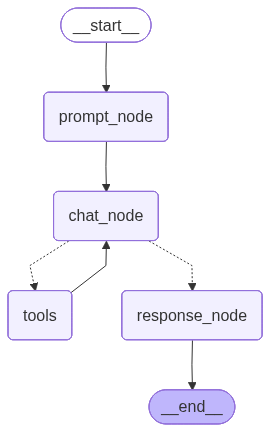

In [207]:
workflow

In [210]:
config = {"configurable": {"thread_id": 13}}

result = workflow.invoke({
    "user_id": "69f47cd803f7c50ab862235b",
    "user_name": "Amit",
    "timezone":  "Asia/Calcutta",
    "query": "which entertainment websites I visited this week?",
    "messages": [HumanMessage(content="which entertainment websites I visited this week?")]
}, config=config)


In [211]:
result

{'user_id': '69f47cd803f7c50ab862235b',
 'user_name': 'Amit',
 'timezone': 'Asia/Calcutta',
 'query': 'which entertainment websites I visited this week?',
 'prompt': 'You are MindMirror, an intelligent personal browsing assistant for Amit.\n\nYour ONLY purpose is to help Amit recall, understand, and explore their personal browsing history.\n\nIMPORTANT CONTEXT:\n- User\'s local timezone is: Asia/Calcutta\n- All browsing session timestamps are stored in Asia/Calcutta local time\n- Current date and time: 03 May 2026, 12:19 AM\n- Today in storage format: 3/5/2026\n- Yesterday in storage format: 2/5/2026\n- Timestamps are stored as D/M/YYYY format (day/month/year)\n- When user says "today" use date: 3/5/2026\n- When user says "yesterday" use date: 2/5/2026\n\nSTRICT RULES:\n- You MUST call search_browsing_history tool before answering ANY question about browsing\n- You MUST pass user_id="69f47cd803f7c50ab862235b" in every single tool call without exception\n- You MUST NEVER make up, guess,

In [212]:
result["messages"]

[HumanMessage(content='which entertainment websites I visited this week?', additional_kwargs={}, response_metadata={}, id='7e4da94f-4ddc-4b4d-a523-2eb56f0fcf86'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 870, 'total_tokens': 909, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3cdb07a9da', 'id': 'chatcmpl-Db9geIwShPgF7Qqi2hEjhx4vGAqxo', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dea05-d056-7992-a2e7-e4959ccc9907-0', tool_calls=[{'name': 'search_browsing_history', 'args': {'user_id': '69f47cd803f7c50ab862235b', 'date': '1/5/2026'}, 'id': 'call_Ixy71O8kRe8zTQySUd5xTV8U', 'type': 'tool_call'}], inva

In [213]:
result["messages"][-1].content

'{"answer":"Hello! This week, you visited a couple of entertainment-related websites. Here are the highlights:\\n\\n1. **YouTube** - You visited this site for some quick entertainment, spending approximately **6 seconds** during one session and **30 seconds** in another. You checked out various videos, including life hacks and food-related content.\\n\\n2. **Reddit** - You spent about **38 seconds** here, where you likely explored various threads and topics related to entertainment.\\n\\nThese visits indicate that you may be interested in watching videos and engaging in discussions around entertainment. \\n\\nLet me know if you\'re looking for specific recommendations or activities related to entertainment!","sources":[{"url":"https://www.youtube.com/","title":"YouTube","domain":"www.youtube.com","openedAt":"1/5/2026, 11:51:22 pm","timeSpent":6164},{"url":"https://www.youtube.com/","title":"YouTube","domain":"www.youtube.com","openedAt":"1/5/2026, 11:49:14 pm","timeSpent":30044},{"url"

In [214]:
json.loads(result["messages"][-1].content)

{'answer': "Hello! This week, you visited a couple of entertainment-related websites. Here are the highlights:\n\n1. **YouTube** - You visited this site for some quick entertainment, spending approximately **6 seconds** during one session and **30 seconds** in another. You checked out various videos, including life hacks and food-related content.\n\n2. **Reddit** - You spent about **38 seconds** here, where you likely explored various threads and topics related to entertainment.\n\nThese visits indicate that you may be interested in watching videos and engaging in discussions around entertainment. \n\nLet me know if you're looking for specific recommendations or activities related to entertainment!",
 'sources': [{'url': 'https://www.youtube.com/',
   'title': 'YouTube',
   'domain': 'www.youtube.com',
   'openedAt': '1/5/2026, 11:51:22 pm',
   'timeSpent': 6164},
  {'url': 'https://www.youtube.com/',
   'title': 'YouTube',
   'domain': 'www.youtube.com',
   'openedAt': '1/5/2026, 11:4

In [55]:
config = {"configurable": {"thread_id": 1}}

result = workflow.invoke({
    "user_id": "69f47cd803f7c50ab862235b",
    "user_name": "Amit",
    "timezone":  "Asia/Calcutta",
    "query": "what did I browse today?",
    "messages": [HumanMessage(content="what I read in medium? and what is explore in reddit?")]
}, config=config)

In [56]:
result

{'user_id': '69f47cd803f7c50ab862235b',
 'user_name': 'Amit',
 'timezone': 'Asia/Calcutta',
 'query': 'what did I browse today?',
 'prompt': 'You are MindMirror, an intelligent personal browsing assistant for Amit.\n\nYour ONLY purpose is to help Amit recall, understand, and explore their personal browsing history.\n\nIMPORTANT CONTEXT:\n- User\'s local timezone is: Asia/Calcutta\n- All browsing session timestamps are stored in Asia/Calcutta local time\n- When user says "today", "yesterday", "this morning" etc, interpret relative to Asia/Calcutta\n- Current date and time in Asia/Calcutta: 02/05/2026, 05:41 PM\n\nSTRICT RULES:\n- You MUST call search_browsing_history tool before answering ANY question about browsing\n- You MUST pass user_id="69f47cd803f7c50ab862235b" in every single tool call without exception\n- You MUST NEVER make up, guess, or hallucinate any browsing data\n- If the tool returns no sessions, honestly tell Amit that no matching browsing history was found\n- If Amit as

In [53]:
result["messages"][-1].content[0]["text"]

"Yes, Amit, when you visited Flipkart yesterday, on January 5th, 2026, the **Flipkart Big Bachat Days sale** was active. This sale ran from January 2nd to January 6th, 2026.\n\nDuring this sale, while smartphones weren't the main focus, you could find discounts on various electronic products. Specifically, there were offers like:\n*   Up to 70% off on large appliances.\n*   55-inch 4K TVs starting from ₹20,99.\n*   27-inch monitors starting from ₹7,299.\n\nAdditionally, customers with Bank of Baroda, HDFC Bank, and RBL Bank cards could get up to a 10% instant discount on EMI transactions."

**Tavily setup**

In [33]:
tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

# test basic search
result = tavily.search(
    query="LangChain tutorial",
    max_results=3
)

In [34]:
result

{'query': 'LangChain tutorial',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://blog.jetbrains.com/pycharm/2026/02/langchain-tutorial-2026/',
   'title': 'LangChain Python Tutorial: A Complete Guide for 2026',
   'content': 'If you’ve read the blog post *How to Build Chatbots With LangChain*, you may want to know more about LangChain. This blog post will dive deeper into what LangChain offers and guide you through a few more real-world use cases. And even if you haven’t read the first post, you might still find the info in this one helpful for building your next AI agent. Let’s have a look at what LangChain is. LangChain provides a standard framework for building AI agents powered by LLMs, like the ones offered by OpenAI, Anthropic, Google, etc., and is therefore the easiest way to get started. LangChain is a high-level tool built on LangGraph, which provides a low-level framework for orchestrating the agent and runtime and is suitable for mo